# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [133]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [134]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [135]:
# ============================================================
# TASK 7
# ResNet-50 Bottleneck Block
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.profiler import profile, ProfilerActivity

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [136]:
#Depthwise Separable Convolution
class DepthwiseSeparableConv(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_channels,
            bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)

        return self.relu(x)

In [137]:
#Bottleneck Block
class BottleneckBlock(nn.Module):

    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):

        super().__init__()

        self.conv1 = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

        self.conv2 = DepthwiseSeparableConv(
            out_channels,
            out_channels,
            stride
        )

        self.conv3 = nn.Sequential(

            nn.Conv2d(
                out_channels,
                out_channels * self.expansion,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels * self.expansion
            )
        )

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels * self.expansion:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels * self.expansion
                )
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)

        out = self.conv2(out)

        out = self.conv3(out)

        out += identity

        out = self.relu(out)

        return out

In [138]:
#Small ResNet
class MiniResNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.layer1 = BottleneckBlock(64,64)

        self.layer2 = BottleneckBlock(256,128,stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(512,10)

    def forward(self,x):

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        return self.fc(x)

In [139]:
#Create Model
model = MiniResNet().to(device)

print(model)

MiniResNet(
  (layer1): BottleneckBlock(
    (conv1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (conv2): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (conv3): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU(inplace=True)
    (shortcut): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum

In [140]:
#Dummy Dataset
x = torch.randn(32,64,64,64).to(device)

y = torch.randint(
    0,
    10,
    (32,)
).to(device)

In [141]:
#Train
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

losses=[]

for epoch in range(10):

    optimizer.zero_grad()

    output = model(x)

    loss = criterion(output,y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(
        f"Epoch {epoch+1} Loss {loss.item():.4f}"
    )

Epoch 1 Loss 2.4042
Epoch 2 Loss 2.2141
Epoch 3 Loss 2.1061
Epoch 4 Loss 2.0365
Epoch 5 Loss 1.9836
Epoch 6 Loss 1.9406
Epoch 7 Loss 1.9004
Epoch 8 Loss 1.8541
Epoch 9 Loss 1.7982
Epoch 10 Loss 1.7343


In [142]:
#Count Parameters
total = sum(
    p.numel()
    for p in model.parameters()
)

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :",total)

print("Trainable Parameters :",trainable)

Total Parameters : 297418
Trainable Parameters : 297418


In [143]:
#PyTorch Profiler
with profile(

    activities=[
        ProfilerActivity.CPU
    ],

    record_shapes=True

) as prof:

    model(x)

print(

    prof.key_averages().table(

        sort_by="cpu_time_total",

        row_limit=15

    )

)

-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                 aten::batch_norm        17.55%       1.922ms        47.39%       5.191ms     648.822us             8  
                                     aten::conv2d         0.73%      79.599us        44.46%       4.870ms     487.025us            10  
                                aten::convolution         1.71%     187.122us        43.74%       4.791ms     479.066us            10  
                               aten::_convolution        10.65%       1.166ms        42.03%       4.604ms     460.353us            10  
                          aten::cudnn_convolutio

In [144]:
activities=[
    ProfilerActivity.CPU,
    ProfilerActivity.CUDA
]

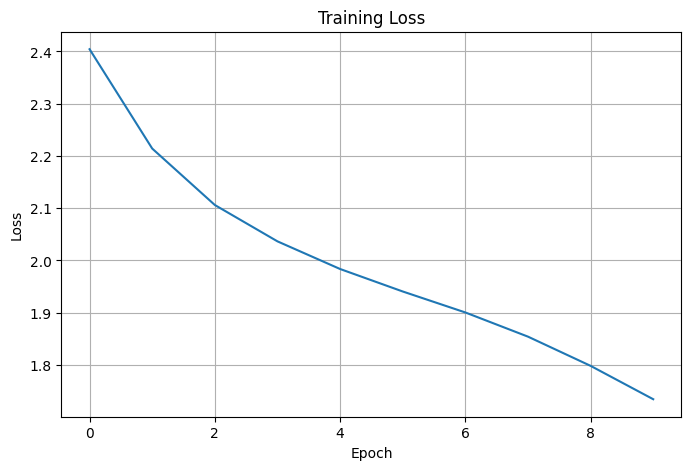

In [145]:
#Loss Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()